1. Настройка окружения

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


В данном блоке импортированы необходимые библиотеки для решения задачи машинного обучения:
pandas - для загрузки и обработки данных; 
matplotlib и seaborn - для визуализации данных и результатов; 
sklearn.model_selection - для разбиения данных на обучающую и тестовую выборки; 
sklearn.preprocessing - для стандартизации числовых признаков; 
sklearn.ensemble (RandomForestClassifier) - для реализации алгоритма «случайный лес» для решения задач классификации; 
sklearn.metrics - для оценки качества предсказаний модели

2. Загрузка и первичный анализ

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Размер датасета: {df.shape[0]} сотрудников и {df.shape[1]} признаков")
print(df.columns)
df.info()
df = df.drop(["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"], axis=1)

Размер датасета: 1470 сотрудников и 35 признаков
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-n

Выполнена загрузка датасета и первичный анализ. Код выводит размерность данных, список признаков и их типы. Также были удалены следующие столбцы: EmployeeNumber, поскольку это уникальный идентификатор сотрудника и никак не влияет на анализ датасета; EmployeeCount, Over18 и StandardHours, поскольку эти столбцы содержат только одно значение - 1, Y и 80. Эти данные также никак не смогут помочь в прогнозировании увольнения сотрудников

3. Разведочный анализ (EDA)


Средний доход и общий стаж по должностям:
                            MonthlyIncome  TotalWorkingYears
JobRole                                                    
Healthcare Representative    7528.763359          14.068702
Human Resources              4235.750000           8.173077
Laboratory Technician        3237.169884           7.656371
Manager                     17181.676471          24.549020
Manufacturing Director       7295.137931          12.786207
Research Director           16033.550000          21.400000
Research Scientist           3239.972603           7.715753
Sales Executive              6924.279141          11.101227
Sales Representative         2626.000000           4.674699


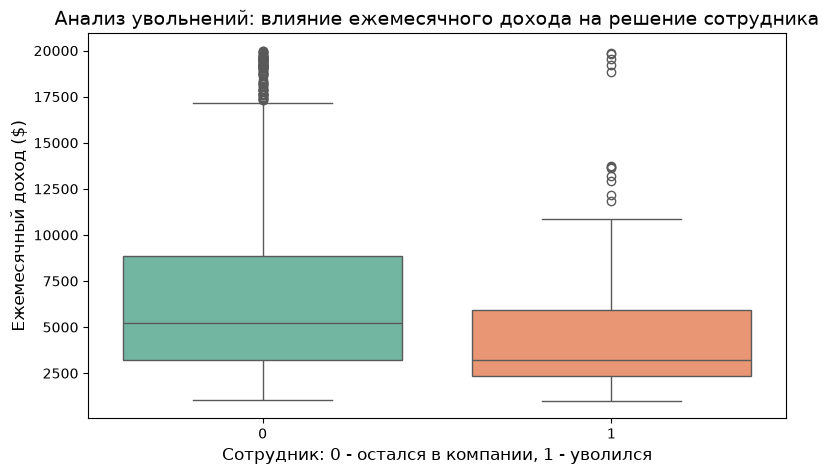

In [ ]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

economic_stats = df.groupby("JobRole")[["MonthlyIncome", "TotalWorkingYears"]].mean()
print("\nСредний доход и общий стаж по должностям:\n", economic_stats)


plt.figure(figsize=(9,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, palette="Set2", 
            legend=False, hue="Attrition")
plt.title("Анализ увольнений: влияние ежемесячного дохода на решение сотрудника",
          fontsize=14)
plt.xlabel("Сотрудник: 0 - остался в компании, 1 - уволился", fontsize=12)
plt.ylabel("Ежемесячный доход ($)", fontsize=12)
plt.show()

Анализ по группировке: можно разделить сотрудников на три группы. К старшему звену относятся сотрудники на должностях Manager и Research Director. У них высокий средний доход и опыт - 17181 и 16033 долларов, 24 и 21 год стажа. К среднему звену относятся сотрудники на должностях Healthcare Representative (представитель по здравоохранению), Manufacturing Director (директор по производству) и Sales Executive (руководитель отдела продаж). Они тоже имеют хороший доход и стаж, но меньше, чем у старшего звена - 7528, 7295 и 6924 долларов, 14, 12 и 11 лет. К младшему звену относятся должности Human Resources (специалист по кадрам), Laboratory Technician и Sales Representative (менеджер по продажам). У них самый низкий средний доход и стаж - 4235, 3237, 3239 и 2626 долларов, 8, 7, 7 и 4 года. У сотрудников на должностях Human Resources, Laboratory Technician и Research Scientist стаж составляет 7-8 лет, но получают они низкую зарплату. Это может говорить о том, что должности недооценены, велик риск увольнения этих сотрудников.

Вывод по графику "Ящик с усами": средний доход уволившихся сотрудников - 3000$, средний доход оставшихся сотрудников - 5000$. Таким образом, сотрудники с более низким доходом чаще принимают решение об увольнении. Однако среди уволившихся есть выбросы, т.е. увольняются и сотрудники с высоким доходом. Можно сделать вывод, что доход не является главной причиной увольнения. Но эйчар-отделу все равно надо обртатить внимание на сотрудников с доходом ниже 3000 $, поскольку они находятся в зоне риска увольнения. Можно создать программу по удержанию таких сотрудников, внедрить какие-то бонусы и плюшки...

4. Feature Engineering и Предобработка

In [ ]:
#подготовка признаков
Y = df["Attrition"]
X = pd.get_dummies(df.drop("Attrition", axis=1), columns=["BusinessTravel", "Department", "EducationField", 
                                                        "Gender", "JobRole", "MaritalStatus", "OverTime"], drop_first=True)
print("Данные после обработки категоральных признаков:")
X.head(3)

Данные после обработки категоральных признаков:


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True


В данном блоке выполнена подготовка признаков для машинного обучения. Категориальные переменные были преобразованы в числовые с помощью One-Hot Encoding. Параметр drop_first=True позволил исключить базовые категории и избежать проблемы мультиколлинеарности

In [ ]:
#масштабирование и разбиение
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, random_state=42, stratify=Y
)

numeric_cols = [
    "Age", 
    "DailyRate", 
    "DistanceFromHome", 
    "HourlyRate", 
    "MonthlyIncome", 
    "MonthlyRate", 
    "NumCompaniesWorked", 
    "PercentSalaryHike", 
    "TotalWorkingYears", 
    "TrainingTimesLastYear", 
    "YearsAtCompany", 
    "YearsInCurrentRole", 
    "YearsSinceLastPromotion", 
    "YearsWithCurrManager"
]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
print("Данные после масштабирования:")
X_train.head(3)

Данные после масштабирования:


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1194,1.090194,1.049455,-0.899915,4,2,-0.908436,4,4,2,2.026752,...,False,True,False,False,False,False,False,False,False,False
128,-1.634828,-0.523449,-0.899915,1,3,1.694111,3,1,4,-0.864408,...,True,False,False,False,False,False,False,True,False,False
810,0.981193,-0.992080,-0.777610,1,1,-0.662913,3,4,3,2.347706,...,False,True,False,False,False,False,False,True,False,False


В данном блоке выполнена подготовка числовых признаков для обучения модели. Исходный набор данных был разделён на тренировочную (80%) и тестовую (20%) выборки. Для числовых признаков выполнено масштабирование, приводящее значения к единому масштабу. Параметры масштабирования рассчитаны на тренировочной выборке, чтобы предотвратить утечку информации из теста и обеспечить корректную оценку модели.

5. Обучение и оценка модели

In [ ]:
model = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight="balanced"
)

model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

accuracy = accuracy_score(Y_test, Y_pred) * 100

print(f"Общая точность модели (Accuracy): {accuracy:.2f}%\n")


Общая точность модели (Accuracy): 83.33%



Точность модели составила 83.33%. Таким образом, использование этой модели позволит эйчар-отделу прогнозировать риски увольнения сотрудников и заранее предпринимать меры по их удержанию, и следовательно снижать затраты на поиск новых сотрудников и их обучение и адаптацию